# Bidirectional LSTM for IMDB Sentiment Analysis

In [5]:
import os
import pandas as pd
import re
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import Counter
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [6]:
csv_path=None
for root,dirs,files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.csv') and 'IMDB' in f:
            csv_path=os.path.join(root,f)
print('Using:',csv_path)
df=pd.read_csv(csv_path)

Using: /kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


In [7]:
def tokenize(text):
    text=text.lower()
    text=re.sub(r'<.*?>','',text)
    text=re.sub(r'[^a-z\s]','',text)
    return text.split()

texts=df['review'].tolist()
labels=df['sentiment'].apply(lambda x:1 if x=='positive' else 0).tolist()
tokens=[tokenize(t) for t in texts]

In [8]:
counter=Counter()
for t in tokens:
    counter.update(t)
vocab={w:i+2 for i,(w,_) in enumerate(counter.most_common(10000))}
vocab['<pad>']=0
vocab['<unk>']=1
vocab_size=len(vocab)

In [9]:
def encode(t): return [vocab.get(w,1) for w in t]

In [10]:
class IMDBDataset(torch.utils.data.Dataset):
    def __init__(self,texts,labels): self.texts=texts; self.labels=labels
    def __len__(self): return len(self.texts)
    def __getitem__(self,idx): return torch.tensor(encode(self.texts[idx])), torch.tensor(self.labels[idx])

In [11]:
def collate_fn(batch):
    texts,labels=zip(*batch)
    max_len=300
    padded=[]
    for t in texts:
        if len(t)<max_len: t=torch.cat([t,torch.zeros(max_len-len(t))])
        else: t=t[:max_len]
        padded.append(t)
    return torch.stack(padded).long(), torch.tensor(labels)

In [12]:
train_texts=tokens[:40000]; train_labels=labels[:40000]
test_texts=tokens[40000:]; test_labels=labels[40000:]

In [13]:
train_loader=DataLoader(IMDBDataset(train_texts,train_labels),batch_size=64,shuffle=True,collate_fn=collate_fn)
test_loader=DataLoader(IMDBDataset(test_texts,test_labels),batch_size=64,collate_fn=collate_fn)

In [14]:
class BiLSTM(nn.Module):
    def __init__(self,vocab_size,embed_dim,hidden_dim):
        super().__init__()
        self.embedding=nn.Embedding(vocab_size,embed_dim)
        self.lstm=nn.LSTM(embed_dim,hidden_dim,batch_first=True,bidirectional=True)
        self.dropout=nn.Dropout(0.5)
        self.fc=nn.Linear(hidden_dim*2,2)
    def forward(self,x):
        x=self.embedding(x)
        out,_=self.lstm(x)
        out=torch.mean(out,dim=1)
        out=self.dropout(out)
        return self.fc(out)

In [15]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model=BiLSTM(vocab_size,100,128).to(device)
optimizer=optim.Adam(model.parameters(),lr=0.0005)
criterion=nn.CrossEntropyLoss()

In [16]:
train_acc_list=[]; val_acc_list=[]

def train():
    model.train(); correct=total=0
    for x,y in train_loader:
        x,y=x.to(device),y.to(device)
        optimizer.zero_grad(); out=model(x); loss=criterion(out,y)
        loss.backward(); optimizer.step()
        pred=out.argmax(1); correct+=(pred==y).sum().item(); total+=y.size(0)
    return correct/total

def evaluate():
    model.eval(); correct=total=0; preds_all=[]; labels_all=[]
    with torch.no_grad():
        for x,y in test_loader:
            x,y=x.to(device),y.to(device)
            out=model(x); pred=out.argmax(1)
            preds_all.extend(pred.cpu()); labels_all.extend(y.cpu())
            correct+=(pred==y).sum().item(); total+=y.size(0)
    return correct/total,preds_all,labels_all

In [17]:
for epoch in range(5):
    train_acc=train(); val_acc,preds,labels=evaluate()
    train_acc_list.append(train_acc); val_acc_list.append(val_acc)
    print(epoch+1,train_acc,val_acc)

1 0.70955 0.8233
2 0.8464 0.8598
3 0.885375 0.872
4 0.90215 0.8805
5 0.9187 0.8815


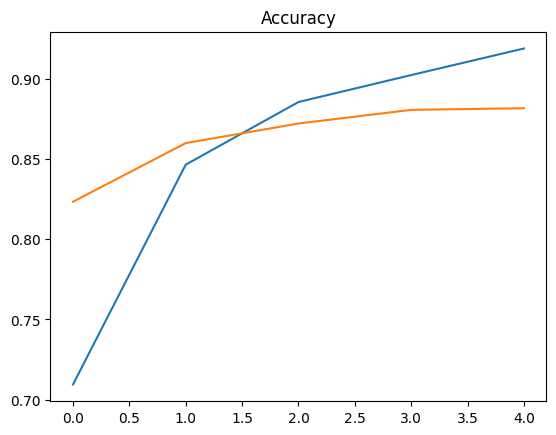

In [18]:
plt.figure()
plt.plot(train_acc_list)
plt.plot(val_acc_list)
plt.title('Accuracy')
plt.show()

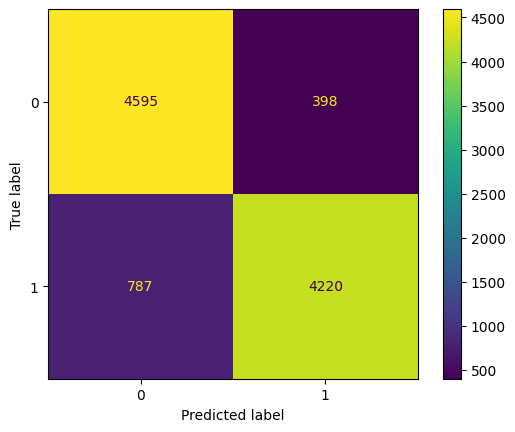

In [19]:
cm=confusion_matrix(labels,preds); ConfusionMatrixDisplay(cm).plot(); plt.show()